In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


abm = pd.read_parquet("../original_case_data/abm.parquet")
card = pd.read_parquet("../original_case_data/card.parquet")
cheque = pd.read_parquet("../original_case_data/cheque.parquet")
eft = pd.read_parquet("../original_case_data/eft.parquet")
emt = pd.read_parquet("../original_case_data/emt.parquet")
westernunion = pd.read_parquet("../original_case_data/westernunion.parquet")
wire = pd.read_parquet("../original_case_data/wire.parquet")

kyc_individual = pd.read_parquet("../original_case_data/kyc_individual.parquet")
kyc_smallbusiness = pd.read_parquet("../original_case_data/kyc_smallbusiness.parquet")
kyc_occupation_codes = pd.read_parquet("../original_case_data/kyc_occupation_codes.parquet")
kyc_industry_codes = pd.read_parquet("../original_case_data/kyc_industry_codes.parquet")

labels = pd.read_parquet("../original_case_data/labels.parquet")

In [4]:
# Add tx_type column to each dataset

abm["tx_type"] = "abm"
card["tx_type"] = "card"
cheque["tx_type"] = "cheque"
eft["tx_type"] = "eft"
emt["tx_type"] = "emt"
westernunion["tx_type"] = "westernunion"
wire["tx_type"] = "wire"

# Concatenate
transactions = pd.concat([
    abm, card, cheque, eft, emt, westernunion, wire
], ignore_index=True)

In [5]:
import networkx as nx

# Nodes:

# customer_id

# transaction context nodes

G = nx.Graph()

for _, row in transactions.iterrows():
    
    cust = row["customer_id"]
    tx_type = row["tx_type"]
    direction = row["debit_credit"]
    
    # Add customer node
    G.add_node(cust, type="customer")
    
    # Connect to transaction type
    G.add_node(tx_type, type="tx_type")
    G.add_edge(cust, tx_type, weight=row["amount_cad"])
    
    # Connect to debit/credit
    dir_node = f"dir_{direction}"
    G.add_node(dir_node, type="direction")
    G.add_edge(cust, dir_node)
    
    # If card transaction, connect merchant_category
    if "merchant_category" in row and pd.notna(row["merchant_category"]):
        mc = f"mcc_{row['merchant_category']}"
        G.add_node(mc, type="merchant")
        G.add_edge(cust, mc)
    
    # If location exists
    if "province" in row and pd.notna(row["province"]):
        prov = f"prov_{row['province']}"
        G.add_node(prov, type="province")
        G.add_edge(cust, prov)

In [11]:
# compute graph metrics for customer nodes
# Degree
cust_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "customer"]
Gc = G.subgraph(cust_nodes).copy()
degree = dict(Gc.degree())

# Betweenness
betweenness = nx.betweenness_centrality(Gc)

# Closeness
closeness = nx.closeness_centrality(Gc)

# Clustering
clustering = nx.clustering(Gc)

# Build graph feature dataframe table

graph_features = []

for node in Gc.nodes():
    if Gc.nodes[node]["type"] == "customer":
        graph_features.append({
            "customer_id": node,
            "degree": degree.get(node, 0),
            "betweenness": betweenness.get(node, 0),
            "closeness": closeness.get(node, 0),
            "clustering": clustering.get(node, 0)
        })

graph_df = pd.DataFrame(graph_features)

KeyboardInterrupt: 

In [8]:
# Graph-based anomaly detection

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

X = graph_df.drop(columns=["customer_id"])

scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42
)

iso.fit(X_scaled)
graph_df["graph_anomaly_score"] = -iso.decision_function(X_scaled)

In [ ]:
# merge to customer-level data

# all_data_graph = all_data.merge(
#     graph_df[["customer_id", "graph_anomaly_score"]],
#     on="customer_id",
#     how="left"
# )

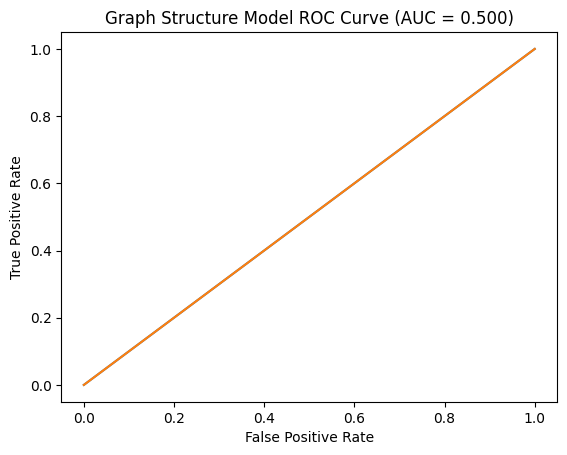

In [9]:
# ROC discrimination of graph anomaly score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

graph_eval = graph_df.merge(labels, on="customer_id", how="left")
labeled_mask = graph_eval["label"].notna()

y_true = graph_eval.loc[labeled_mask, "label"].astype(int)
y_score = graph_eval.loc[labeled_mask, "graph_anomaly_score"]

auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"Graph Structure Model ROC Curve (AUC = {auc:.3f})")
plt.show()

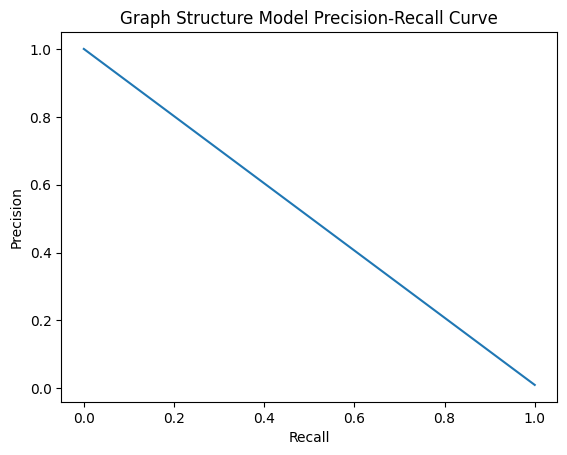

In [10]:
# PR-AUC
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_true, y_score)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Graph Structure Model Precision-Recall Curve")
plt.show()

In [ ]:
# Connectivity vs anomaly score
# plt.figure()
# plt.scatter(graph_eval["degree"], graph_eval["graph_anomaly_score"])
# plt.xlabel("Graph Degree (Number of Connections)")
# plt.ylabel("Graph Anomaly Score")
# plt.title("Customer Connectivity vs Anomaly Score")
# plt.show()

In [ ]:
# Subgraph of high anomaly score customers

import networkx as nx

top_nodes = graph_eval.sort_values(
    "graph_anomaly_score", ascending=False
).head(10)["customer_id"]

subG = G.subgraph(top_nodes)

plt.figure()
nx.draw(subG, with_labels=True, node_size=500)
plt.title("Subgraph of Top 10 Structurally Anomalous Customers")
plt.show()